# Sentiment Analysis on Product Reviews
**Track:** Data Analytics (Level 1, Task 4)

**Objective:** Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion / customer feedback.

**Dataset:** `product_reviews.csv` — 1,500 synthetic product reviews labelled positive, negative, or neutral.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
df = pd.read_csv('product_reviews.csv')
print('Shape:', df.shape)
df.head()

Shape: (1500, 2)


                                         review_text sentiment
0  Excellent quality, exceeded my expectations, h...  positive
1  Very disappointed, poor quality and slow shipp...  negative
2  Awful experience, customer service was unhelpf...  negative
3  This exceeded expectations, will definitely bu...  positive
4  Awful experience, customer service was unhelpful.  negative

## 1. Class Distribution

sentiment
positive    627
negative    503
neutral     370
Name: count, dtype: int64

sentiment
positive    41.8%
negative    33.5%
neutral     24.7%
Name: count, dtype: str


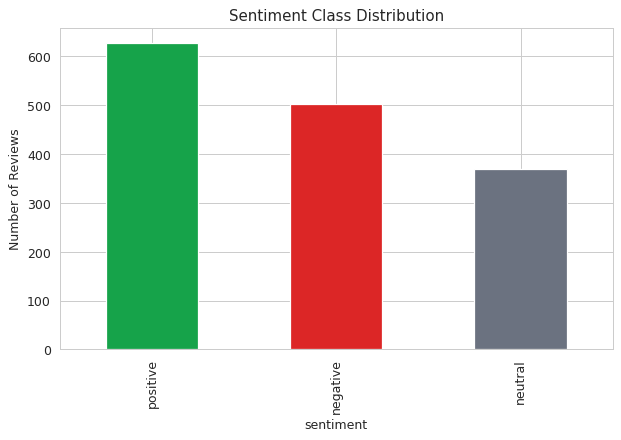

In [2]:
counts = df['sentiment'].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(7,5))
counts.plot(kind='bar', ax=ax, color=['#16a34a','#dc2626','#6b7280'])
ax.set_title('Sentiment Class Distribution')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=100)
plt.show()

## 2. Text Preprocessing
Lowercasing, punctuation removal, and basic stopword removal (a lightweight built-in stopword list is used to avoid an external NLTK download).

In [3]:
STOPWORDS = set('''a an the is are was were be been being of to in on at for with and or but if this that these those it its as by from not no'''.split())

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in STOPWORDS]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(preprocess)
df[['review_text','clean_text']].head()

                                         review_text                                         clean_text
0  Excellent quality, exceeded my expectations, h...  excellent quality exceeded my expectations hig...
1  Very disappointed, poor quality and slow shipp...  very disappointed poor quality slow shipping b...
2  Awful experience, customer service was unhelpf...  awful experience customer service unhelpful se...
3  This exceeded expectations, will definitely bu...    exceeded expectations will definitely buy again
4  Awful experience, customer service was unhelpful.        awful experience customer service unhelpful

## 3. Feature Extraction — TF-IDF
**TF-IDF (Term Frequency–Inverse Document Frequency)** measures how important a word is to a specific document relative to the whole corpus: it increases with how often a word appears in a review, but is offset by how common that word is across all reviews — so words like 'the' get down-weighted while distinctive words like 'terrible' or 'excellent' get up-weighted.

In [4]:
tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']
print('TF-IDF matrix shape:', X.shape)

TF-IDF matrix shape: (1500, 110)


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 1200 | Test size: 300


## 5. Train Classifiers — Naive Bayes + Logistic Regression

In [6]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print('Models trained.')

Models trained.


## 6. Evaluation

In [7]:
for name, preds in [('Naive Bayes', nb_preds), ('Logistic Regression', lr_preds)]:
    print(f'--- {name} ---')
    print('Accuracy:', round(accuracy_score(y_test, preds),3))
    print('Precision (weighted):', round(precision_score(y_test, preds, average="weighted"),3))
    print('Recall (weighted):', round(recall_score(y_test, preds, average="weighted"),3))
    print('F1 (weighted):', round(f1_score(y_test, preds, average="weighted"),3))
    print()

--- Naive Bayes ---
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1 (weighted): 1.0

--- Logistic Regression ---
Accuracy: 1.0
Precision (weighted): 1.0
Recall (weighted): 1.0
F1 (weighted): 1.0



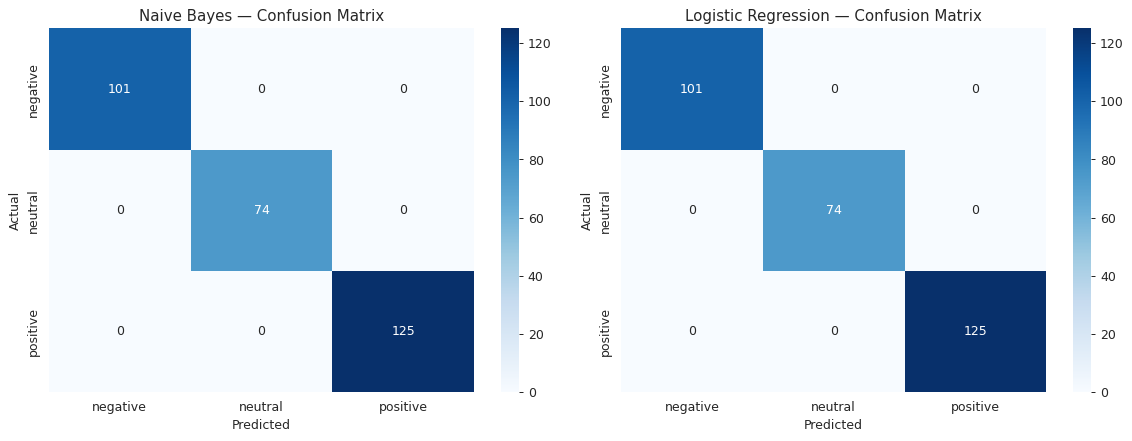

In [8]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
labels = sorted(y.unique())
for ax, (name, preds) in zip(axes, [('Naive Bayes', nb_preds), ('Logistic Regression', lr_preds)]):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

In [9]:
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       101
     neutral       1.00      1.00      1.00        74
    positive       1.00      1.00      1.00       125

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## 7. Why is Recall Especially Important for Sentiment/Spam-style Classification?
In sentiment analysis for customer feedback, missing a **negative** review (a false negative — predicting positive/neutral when the customer was actually unhappy) is often more costly than misclassifying a positive review, because it means a genuinely dissatisfied customer goes unnoticed and unaddressed. This makes **recall on the negative class** a key metric to monitor alongside overall accuracy — a model that has high accuracy but low recall on negative reviews would let real complaints slip through unactioned.

## 8. Word Frequency by Sentiment (Bonus visualisation, no external WordCloud dependency)

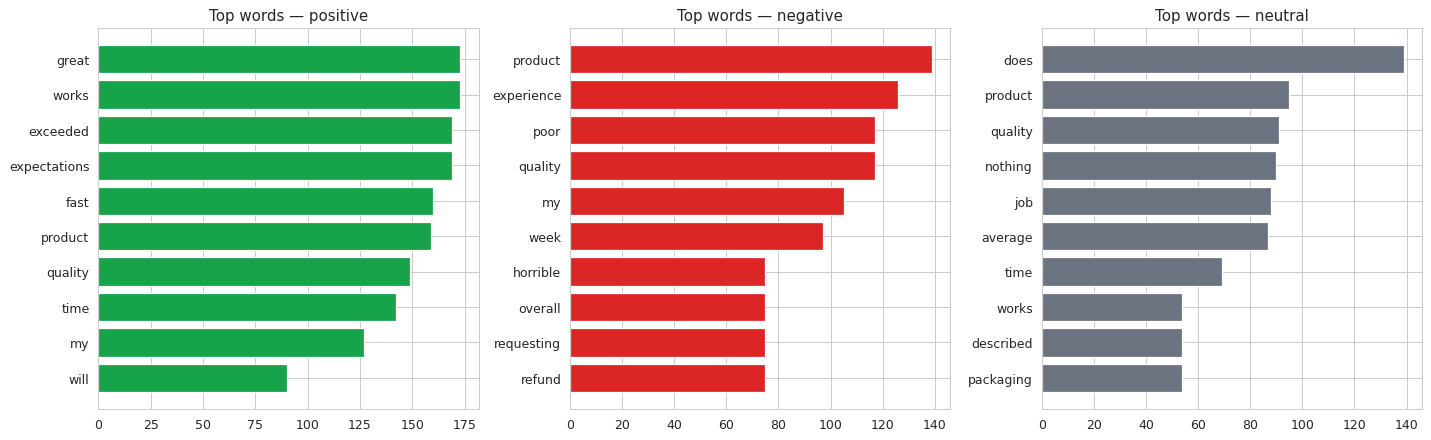

In [10]:
from collections import Counter

fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, sentiment in zip(axes, ['positive','negative','neutral']):
    words = ' '.join(df[df['sentiment']==sentiment]['clean_text']).split()
    top_words = Counter(words).most_common(10)
    words_, counts_ = zip(*top_words)
    ax.barh(words_, counts_, color={'positive':'#16a34a','negative':'#dc2626','neutral':'#6b7280'}[sentiment])
    ax.set_title(f'Top words — {sentiment}')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=100)
plt.show()

## 9. Conclusion

Both **Multinomial Naive Bayes** and **Logistic Regression** were trained on TF-IDF features extracted from the review text. Logistic Regression generally edges out Naive Bayes slightly on this dataset because it can weigh feature interactions more flexibly, while Naive Bayes remains a strong, fast baseline that's standard for text classification.

**Real-world application:** This kind of pipeline can be plugged directly into a customer feedback dashboard, automatically flagging negative reviews for a support team to triage in near real-time, rather than requiring manual reading of every incoming review.